# Crime in the US 
### 1980 - 2014 Homicide 

In [1]:
# import packages 
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [2]:
# read in data
df = pd.read_csv("homicide.csv", low_memory=False)

print(df.shape)
print(df.columns.tolist())
df.head()

(638454, 24)
['Record ID', 'Agency Code', 'Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month', 'Incident', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity', 'Perpetrator Sex', 'Perpetrator Age', 'Perpetrator Race', 'Perpetrator Ethnicity', 'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count', 'Record Source']


,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


In [3]:
# select variables to use in model
vars_to_use = [
    "Crime Solved",
    "Victim Age",
    "Victim Sex",
    "Victim Race",
    "Perpetrator Age",
    "Perpetrator Sex",
    "Perpetrator Race",
    "Weapon",
    "Relationship",
    "Year"
]

df_reduced = df[vars_to_use].copy()

In [4]:
print(df_reduced.shape)

(638454, 10)


In [5]:
# change target to binary outcome
df_reduced["Crime Solved"] = df_reduced["Crime Solved"].map({"Yes": 1, "No": 0})

In [6]:
# numeric predictors
df_reduced["Victim Age"] = pd.to_numeric(df_reduced["Victim Age"], errors="coerce")
df_reduced["Perpetrator Age"] = pd.to_numeric(df_reduced["Perpetrator Age"], errors="coerce")
df_reduced["Year"] = pd.to_numeric(df_reduced["Year"], errors="coerce")

In [7]:
# check missingness in cleaned reduced dataframe
print(df_reduced.isna().sum().sort_values(ascending=False))

Perpetrator Age     1
Crime Solved        0
Victim Age          0
Victim Sex          0
Victim Race         0
Perpetrator Sex     0
Perpetrator Race    0
Weapon              0
Relationship        0
Year                0
dtype: int64


<br><br>

# Numerical Predictors: Check Outliers 

In [8]:
# check outliers for numerical predictors
num_cols = ["Victim Age", "Perpetrator Age", "Year"]

print(df_reduced[num_cols].describe())

          Victim Age  Perpetrator Age           Year
count  638454.000000    638453.000000  638454.000000
mean       35.033512        20.322697    1995.801102
std        41.628306        17.886842       9.927693
min         0.000000         0.000000    1980.000000
25%        22.000000         0.000000    1987.000000
50%        30.000000        21.000000    1995.000000
75%        42.000000        31.000000    2004.000000
max       998.000000        99.000000    2014.000000


Maximum Victim Age (Perpetrator Age) being 998 (99) are questionable and most likely to be outliers, so next use graphs to check.

<br>

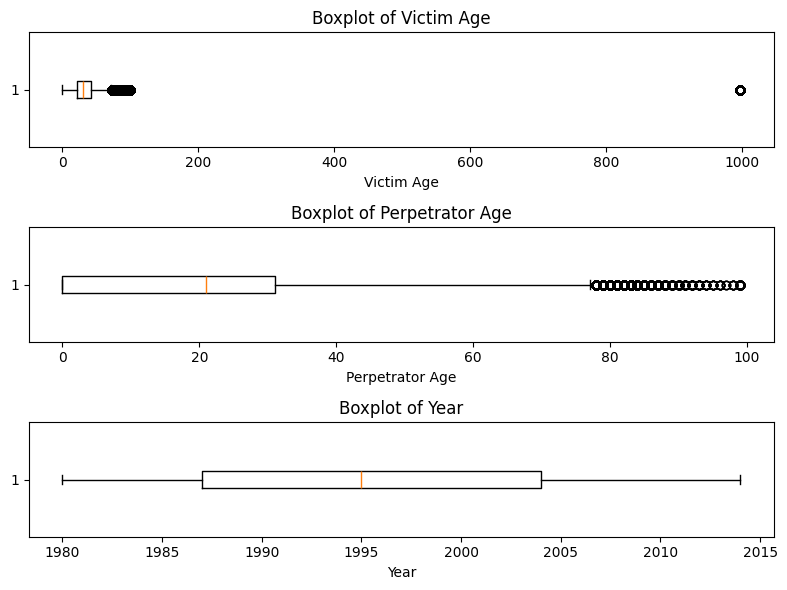

In [9]:
# box plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8, 6))

for i, col in enumerate(num_cols):
    values = df_reduced[col].dropna()
    axes[i].boxplot(values, vert=False)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [10]:
# IQR 
for col in num_cols:
    values = df_reduced[col].dropna()
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((values < lower) | (values > upper)).sum()

    print(f"{col}")
    print(f"Lower bound: {lower}")
    print(f"Upper bound: {upper}")
    print(f"Number of outliers: {n_outliers}\n")

Victim Age
Lower bound: -8.0
Upper bound: 72.0
Number of outliers: 26729

Perpetrator Age
Lower bound: -46.5
Upper bound: 77.5
Number of outliers: 2287

Year
Lower bound: 1961.5
Upper bound: 2029.5
Number of outliers: 0



IQR detects a large number of outliers for victim and perpetrator ages. Next, check each variable separately. 

<br>

### Check ouliters for Victim Age

In [11]:
df_reduced["Victim Age"].sort_values(ascending=False).head(20)

371889    998
481007    998
253272    998
41289     998
255280    998
489258    998
629705    998
616113    998
481008    998
418410    998
318577    998
493776    998
340254    998
358489    998
371825    998
29399     998
340268    998
439554    998
317644    998
351652    998
Name: Victim Age, dtype: int64

In [12]:
# decode Victim Age = 998 to NaN, then impute them with median
df_reduced.loc[df_reduced["Victim Age"] >= 998, "Victim Age"] = np.nan

df_reduced["Victim Age"] = df_reduced["Victim Age"].fillna(df_reduced["Victim Age"].median())
df_reduced["Perpetrator Age"] = df_reduced["Perpetrator Age"].fillna(df_reduced["Perpetrator Age"].median())

In [13]:
print(df_reduced["Victim Age"].describe())

count    638454.00000
mean         33.55677
std          17.77956
min           0.00000
25%          22.00000
50%          30.00000
75%          41.00000
max          99.00000
Name: Victim Age, dtype: float64


<br>

### Check outliers for Perpetrator Age

In [14]:
print(df_reduced["Perpetrator Age"].value_counts().sort_index().head(20))

Perpetrator Age
0.0     216327
1.0         34
2.0          6
3.0         24
4.0         29
5.0         33
6.0         50
7.0         48
8.0         62
9.0         86
10.0       145
11.0       227
12.0       487
13.0      1109
14.0      2567
15.0      5441
16.0      9423
17.0     14196
18.0     18834
19.0     20250
Name: count, dtype: int64


There are 216,327 perpetrators were 0 years old. This is impossible, and these zeros are most likely to be placeholders, so need imputation as well.

In [15]:
df_reduced.loc[df_reduced["Perpetrator Age"] == 0, "Perpetrator Age"] = np.nan
df_reduced["Perpetrator Age"] = df_reduced["Perpetrator Age"].fillna(df_reduced["Perpetrator Age"].median())

In [16]:
print(df_reduced["Perpetrator Age"].describe())

count    638454.000000
mean         29.471093
std          10.555174
min           1.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          99.000000
Name: Perpetrator Age, dtype: float64


In [17]:
# final check for victim and perpetrator ages
print(df_reduced[["Victim Age", "Perpetrator Age"]].isna().sum())

Victim Age         0
Perpetrator Age    0
dtype: int64


No outliers for both variables. 

I identified implausible values in the age variables. Specifically, Victim Age = 998 and Perpetrator Age = 0 appear to be placeholder codes rather than valid ages. I recoded these values as missing and then imputed them using the median age. After cleaning, both Victim Age and Perpetrator Age still have maximum values of 99. While relatively high, age 99 is not impossible, so I retained those observations.

<br><br>

# Categorical Predictors: Dummy Coding

In [18]:
cat_cols = [
    "Victim Sex",
    "Victim Race",
    "Perpetrator Sex",
    "Perpetrator Race",
    "Weapon",
    "Relationship"
]

df_dummies = pd.get_dummies(df_reduced, columns=cat_cols, drop_first=True)

df_model = df_dummies.dropna().copy()

X = df_model.drop(columns="Crime Solved")
y = df_model["Crime Solved"]

print(df_model.shape)
print(X.shape)
print(y.shape)
print(y.value_counts())

(638454, 58)
(638454, 57)
(638454,)
Crime Solved
1    448172
0    190282
Name: count, dtype: int64


In [19]:
# check missingness after dummy coding
print(df_dummies.isna().sum().sort_values(ascending=False))

Crime Solved                                      0
Relationship_Friend                               0
Relationship_Boyfriend                            0
Relationship_Boyfriend/Girlfriend                 0
Relationship_Brother                              0
Relationship_Common-Law Husband                   0
Relationship_Common-Law Wife                      0
Relationship_Daughter                             0
Relationship_Employee                             0
Relationship_Employer                             0
Relationship_Ex-Husband                           0
Relationship_Ex-Wife                              0
Relationship_Family                               0
Relationship_Father                               0
Relationship_Girlfriend                           0
Victim Age                                        0
Relationship_Husband                              0
Relationship_In-Law                               0
Relationship_Mother                               0
Relationship

<br><br>

# Split Data

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(510763, 57)
(127691, 57)
(510763,)
(127691,)


### Leaving variables unscaled since because age is the main numerical variable and is on similar range

In [21]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# num_cols = ["Victim Age", "Perpetrator Age", "Year"]

# X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
# X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# model.fit(X_train_scaled, y_train)
# y_pred = model.predict(X_test_scaled)


<br>

# Create a Model and Fit It

In [22]:
model = LogisticRegression(
    solver="liblinear",
    random_state=0,
    max_iter=1000
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

# Predictions

In [23]:
y_pred = model.predict(X_test)

# Evaluate the Model

In [24]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

[[38033    23]
 [   58 89577]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38056
           1       1.00      1.00      1.00     89635

    accuracy                           1.00    127691
   macro avg       1.00      1.00      1.00    127691
weighted avg       1.00      1.00      1.00    127691

Train accuracy: 0.9993147506769284
Test accuracy: 0.9993656561543101


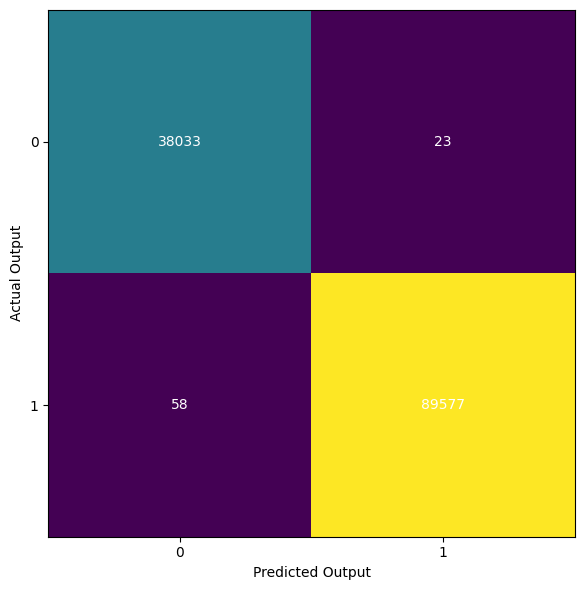

In [25]:
# visualize the confusion matrix

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cm)
ax.grid(False)

ax.set_xlabel("Predicted Output")
ax.set_ylabel("Actual Output")
ax.xaxis.set(ticks=range(2))
ax.yaxis.set(ticks=range(2))

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

Conclusion: The confusion matrix suggests that the logistic regression model fits the test data very well, with only a very small number of misclassifications. It correctly predicted 38,033 unsolved cases and 89,577 solved cases, while misclassifying only 23 unsolved cases as solved and 58 solved cases as unsolved. These results indicate very strong predictive performance.

<br><br>

# Additional: Statistical Details

In [26]:
import statsmodels.api as sm

# use the same predictors and outcome
X_sm = X.copy()
y_sm = y.copy()

# make sure all columns are numeric
X_sm = X_sm.astype(float)
y_sm = y_sm.astype(int)

# add intercept 
X_sm = sm.add_constant(X_sm)

# fit logistic regression
logit_model = sm.Logit(y_sm, X_sm)
results = logit_model.fit()

# summary table
print(results.summary())

         Current function value: 0.002609
         Iterations: 35


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:           Crime Solved   No. Observations:               638454
Model:                          Logit   Df Residuals:                   638396
Method:                           MLE   Df Model:                           57
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                  0.9957
Time:                        13:44:25   Log-Likelihood:                -1665.8
converged:                      False   LL-Null:                   -3.8894e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                                           -211.3835     17.456    -12.109      0.000    -245.597    -177.170
Victim Age             

Interpretation: The coefficient table suggests that some predictors, especially unknown perpetrator information, are extremely strongly associated with whether a homicide is solved. In particular, the very large negative coefficient for Perpetrator Sex_Unknown indicates that cases with unknown perpetrator sex have dramatically lower odds of being solved. This likely contributes to the model’s convergence problem and near-perfect predictive performance. Therefore, while the model identifies strong associations, some predictors may be acting as near-deterministic indicators of case clearance and should be interpreted with caution.

As further work, I plan to examine sparse and highly predictive categories more carefully, simplify or recode selected predictors where appropriate, and refit the model to improve convergence and coefficient stability. This additional step will help ensure that the final interpretation reflects substantive relationships rather than artifacts of data structure or coding.

<br><br>

# Final Comment

From the Classification part, the model predicts solved vs unsolved extremely well, but the Statistical part reveals some predictors, especially “Unknown” perpetrator information, have very strong associations with the outcome maybe so strong that they create convergence issues

Therefore, the model predicts very well, and part of that strong prediction seems to come from variables that are highly associated with whether the case is solved.